# Hypergraph Construction

Builds the UniPi hypergraph from the full citation graph.

- **Nodes**: UniPi papers (post-2020 + parents)
- **Hyperedges**: each external reference connecting ≥2 UniPi papers that cite it
- **Direct citations excluded** from hyperedge construction to isolate the BC signal

Pipeline: load full graph → filter post-2020 → build orbits → deduplicate → filter hubs → enrich attributes → save.

In [1]:
import json
import os
import pickle
import re
from collections import Counter, defaultdict
from pathlib import Path

import hypernetx as hnx
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

BASE_DIR = Path().resolve().parent.parent
GRAPH_DIR = BASE_DIR / "data" / "graph"
FULL_GRAPH_PATH = GRAPH_DIR / "A_graph_creation" / "A_source_graph.gpickle"

OUTPUT_DIR = Path().resolve() / "output"
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_GRAPH = BASE_DIR / "data" / "hypergraph"

YEAR_THRESHOLD = 2020
MIN_HE_SIZE = 2     # min UniPi papers per hyperedge
MAX_HUB = 450        # max UniPi papers per external ref

## 1. Load full citation graph and remove ext→ext edges

In [2]:
with open(FULL_GRAPH_PATH, "rb") as f:
    G_raw = pickle.load(f)

print(f"G_raw: {G_raw.number_of_nodes():,} nodes, {G_raw.number_of_edges():,} edges")

is_unipi = {n: bool(d.get("is_unipi", False)) for n, d in G_raw.nodes(data=True)}
N_unipi = sum(is_unipi.values())
N_ext = G_raw.number_of_nodes() - N_unipi

# Remove ext→ext edges (no information for UniPi analysis)
e2e = [(u, v) for u, v in G_raw.edges() if not is_unipi.get(u, False) and not is_unipi.get(v, False)]
G_clean = G_raw.copy()
G_clean.remove_edges_from(e2e)

print(f"UniPi nodes: {N_unipi:,}  |  External nodes: {N_ext:,}")
print(f"Removed {len(e2e):,} ext→ext edges  |  Remaining: {G_clean.number_of_edges():,} edges")

G_raw: 4,859,300 nodes, 8,271,912 edges
UniPi nodes: 134,628  |  External nodes: 4,724,672
Removed 8,982 ext→ext edges  |  Remaining: 8,262,930 edges


## 2. Post-2020 selection

Keep three node groups:
1. **Recent UniPi** with publication year ≥ 2020
2. **Parent UniPi** cited by recent UniPi (older or missing year)
3. **External nodes** connected to surviving UniPi in either direction

In [3]:
YEAR_RE = re.compile(r"(19|20)\d{2}")

def extract_year(value):
    if isinstance(value, (int, float)):
        y = int(value)
        return y if 1900 <= y <= 2100 else None
    if isinstance(value, str):
        m = YEAR_RE.search(value)
        return int(m.group(0)) if m else None
    return None

# Partition nodes
unipi_by_year = {}
unipi_no_year = set()
external_all = set()

for node, attrs in G_clean.nodes(data=True):
    if attrs.get("is_unipi", False):
        year = extract_year(attrs.get("publicationDate"))
        if year is None:
            unipi_no_year.add(node)
        else:
            unipi_by_year[node] = year
    else:
        external_all.add(node)

recent_unipi = {n for n, y in unipi_by_year.items() if y >= YEAR_THRESHOLD}

# Parents: UniPi papers cited by recent ones, older than threshold or missing year
parent_unipi = set()
for n in recent_unipi:
    for cited in G_clean.successors(n):
        y = unipi_by_year.get(cited)
        if (y is not None and y < YEAR_THRESHOLD) or (cited in unipi_no_year):
            parent_unipi.add(cited)

surviving_unipi = recent_unipi | parent_unipi

# External nodes connected to surviving UniPi
external_nodes = set()
for n in surviving_unipi:
    for nbr in G_clean.successors(n):
        if nbr in external_all:
            external_nodes.add(nbr)
    for nbr in G_clean.predecessors(n):
        if nbr in external_all:
            external_nodes.add(nbr)

selected = surviving_unipi | external_nodes
G_sub = G_clean.subgraph(selected).copy()

print(f"Year threshold  : {YEAR_THRESHOLD}")
print(f"Surviving UniPi : {len(surviving_unipi):,}  (recent: {len(recent_unipi):,}, parent: {len(parent_unipi):,})")
print(f"External nodes  : {len(external_nodes):,}")
print(f"G_sub           : {G_sub.number_of_nodes():,} nodes, {G_sub.number_of_edges():,} edges")

Year threshold  : 2020
Surviving UniPi : 64,156  (recent: 38,104, parent: 26,052)
External nodes  : 3,014,451
G_sub           : 3,078,607 nodes, 5,033,695 edges


## 3. Build hyperedge orbits

For each external reference, collect all UniPi papers connected to it (citing or cited by).
Filter to hyperedges with ≥2 UniPi nodes.

In [4]:
is_unipi_sub = {n: bool(d.get("is_unipi", False)) for n, d in G_sub.nodes(data=True)}

# external_id → set of UniPi papers linked in either direction
unipi_by_external = defaultdict(set)

for u, v in G_sub.edges():
    u_is = is_unipi_sub.get(u, False)
    v_is = is_unipi_sub.get(v, False)
    if u_is and not v_is:       # UniPi → External
        unipi_by_external[v].add(u)
    elif not u_is and v_is:     # External → UniPi
        unipi_by_external[u].add(v)

# Filter: min 2 UniPi nodes per hyperedge
raw_hyperedges = {
    ext_id: sorted(nodes)
    for ext_id, nodes in unipi_by_external.items()
    if len(nodes) >= MIN_HE_SIZE
}

print(f"Raw hyperedges (≥{MIN_HE_SIZE} UniPi nodes): {len(raw_hyperedges):,}")

# Build incidence table
incidence_rows = []
for ext_id, nodes in raw_hyperedges.items():
    incidence_rows.extend({"edge": ext_id, "node": node} for node in nodes)

incidence_raw = pd.DataFrame(incidence_rows)
print(f"Incidence rows: {len(incidence_raw):,}")
print(f"Unique nodes in hypergraph: {incidence_raw['node'].nunique():,}")

Raw hyperedges (≥2 UniPi nodes): 762,800
Incidence rows: 2,561,750
Unique nodes in hypergraph: 61,370


## 4. Deduplicate hyperedges

Multiple external references may connect the exact same set of UniPi papers.
These are semantically redundant — we collapse them into weighted "families".

In [5]:
edge_to_nodes = incidence_raw.groupby("edge")["node"].agg(lambda s: tuple(sorted(set(s)))).to_dict()

nodes_to_edges = defaultdict(list)
for edge_id, node_tuple in edge_to_nodes.items():
    nodes_to_edges[node_tuple].append(edge_id)

families_df = pd.DataFrame(
    {
        "family_id": f"FAM_{i:07d}",
        "size": len(node_tuple),
        "weight": len(edge_list),
        "node_list": list(node_tuple),
        "source_edges": edge_list,
    }
    for i, (node_tuple, edge_list) in enumerate(nodes_to_edges.items(), start=1)
)

n_raw = incidence_raw["edge"].nunique()
n_fam = len(families_df)
dup_rate = (n_raw - n_fam) / n_raw

print(f"Original hyperedges : {n_raw:,}")
print(f"Unique families     : {n_fam:,}")
print(f"Duplicate rate      : {dup_rate:.1%}")
print(f"Max weight (most duplicated): {families_df['weight'].max()}")

Original hyperedges : 762,800
Unique families     : 512,004
Duplicate rate      : 32.9%
Max weight (most duplicated): 1535


## 5. Hub filter

Remove hyperedges with >MAX_HUB UniPi nodes — these are foundational references
cited across disciplines that generate spurious connections (same logic as pairwise BC).

In [6]:
families_filtered = families_df[
    (families_df["size"] >= MIN_HE_SIZE) & (families_df["size"] <= MAX_HUB)
].copy()

n_removed = len(families_df) - len(families_filtered)

# Build filtered incidence table
incidence_filtered = (
    families_filtered[["family_id", "weight", "node_list"]]
    .explode("node_list")
    .rename(columns={"family_id": "edge", "node_list": "node"})
    .reset_index(drop=True)
)

print(f"Hub filter: min_size={MIN_HE_SIZE}, max_hub={MAX_HUB}")
print(f"Hyperedges removed  : {n_removed:,}")
print(f"Hyperedges kept     : {len(families_filtered):,}")
print(f"Incidence rows      : {len(incidence_filtered):,}")
print(f"Nodes in final HG   : {incidence_filtered['node'].nunique():,}")

# Quick structural stats
node_deg = incidence_filtered.groupby("node")["edge"].nunique()
he_sizes = families_filtered["size"]

print(f"\nNode degree:  median={node_deg.median():.0f}  mean={node_deg.mean():.1f}  max={node_deg.max()}")
print(f"HE size:      median={he_sizes.median():.0f}  mean={he_sizes.mean():.1f}  max={he_sizes.max()}")
print(f"Singletons:   {(node_deg == 1).sum():,} ({(node_deg == 1).mean():.1%})")

Hub filter: min_size=2, max_hub=450
Hyperedges removed  : 14
Hyperedges kept     : 511,990
Incidence rows      : 1,976,602
Nodes in final HG   : 61,369

Node degree:  median=19  mean=32.2  max=6061
HE size:      median=3  mean=3.9  max=423
Singletons:   2,469 (4.0%)


## 6. Enrich node attributes

Attach FOS L2/L4, SDG, title, and year to hypergraph nodes from the original graph.

In [7]:
_LEVEL_RE = {
    "L2": re.compile(r"^\d{2}\s"),
    "L4": re.compile(r"^\d{4}\s"),
}

def parse_fos(fos_string, level="L4"):
    if not fos_string:
        return []
    labels = [l.strip() for l in fos_string.split(";") if l.strip()]
    pat = _LEVEL_RE.get(level)
    return [l for l in labels if pat.match(l)] if pat else labels

hg_nodes = set(incidence_filtered["node"].unique())
node_attrs = {}

for node in hg_nodes:
    if node not in G_sub.nodes:
        continue
    data = G_sub.nodes[node]
    node_attrs[node] = {
        "fos_L2": parse_fos(data.get("FOS", ""), "L2"),
        "fos_L4": parse_fos(data.get("FOS", ""), "L4"),
        "sdg": data.get("SDG", ""),
        "title": data.get("mainTitle", ""),
        "year": extract_year(data.get("publicationDate")),
        "is_recent": node in recent_unipi,
        "is_parent": node in parent_unipi,
    }

n_with_fos = sum(1 for a in node_attrs.values() if a["fos_L4"])
print(f"Nodes with attributes: {len(node_attrs):,} / {len(hg_nodes):,}")
print(f"Nodes with FOS L4:     {n_with_fos:,} ({n_with_fos/len(hg_nodes):.1%})")

Nodes with attributes: 61,369 / 61,369
Nodes with FOS L4:     46,500 (75.8%)


## 7. Distributions

=== Filter overlay for scatter plots ===
Visual filter             : fixed min_size = 2, max_hub <= 450
Affected edges            : 14
Unaffected edges          : 762,786
Affected nodes            : 2,081
Unaffected nodes          : 59,289
Nodes degree-changed      : 2,081


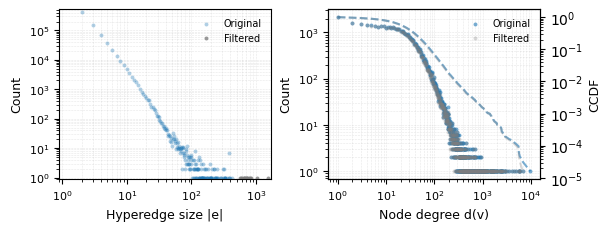

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VIS_MAX_HUB_PLOT = 450

def build_filter_overlay(inc_table: pd.DataFrame, max_hub: int = 450) -> dict:
    e_sizes = inc_table.groupby("edge")["node"].nunique()
    n_deg = inc_table.groupby("node")["edge"].nunique()
    kept_edges = e_sizes[(e_sizes >= 2) & (e_sizes <= max_hub)].index
    removed_edges = e_sizes.index.difference(kept_edges)
    affected_nodes = set(inc_table.loc[inc_table["edge"].isin(removed_edges), "node"])

    return {
        "edge_sizes": e_sizes,
        "node_deg": n_deg,
        "kept_edges": kept_edges,
        "removed_edges": removed_edges,
        "affected_nodes": affected_nodes,
        "affected_nodes_deg": n_deg[n_deg.index.isin(affected_nodes)],
        "node_deg_kept": inc_table[inc_table["edge"].isin(kept_edges)].groupby("node")["edge"].nunique(),
    }

# =========================
# CHECK DEPENDENCIES
# =========================
incidence_df = pd.DataFrame(incidence_rows)
H = hnx.Hypergraph(incidence_filtered[["edge", "node"]], edge_col="edge", node_col="node")
# =========================
# BUILD OVERLAY
# =========================
overlay = build_filter_overlay(incidence_df, max_hub=VIS_MAX_HUB_PLOT)

edge_sizes = overlay["edge_sizes"]
node_deg = overlay["node_deg"]

affected_edge_ids = pd.Index(overlay["removed_edges"])
unaffected_edge_ids = pd.Index(overlay["kept_edges"])

affected_nodes = pd.Index(sorted(overlay["affected_nodes"]))
unaffected_nodes = pd.Index(node_deg.index).difference(affected_nodes)

# =========================
# FREQUENCIES
# =========================
edge_freq_affected = edge_sizes[edge_sizes.index.isin(affected_edge_ids)].value_counts().sort_index()
edge_freq_unaffected = edge_sizes[edge_sizes.index.isin(unaffected_edge_ids)].value_counts().sort_index()
edge_freq_all = edge_sizes.value_counts().sort_index()

node_freq_original = node_deg.value_counts().sort_index()
node_freq_filtered = node_deg[node_deg.index.isin(unaffected_nodes)].value_counts().sort_index()

changed_nodes = (node_deg - overlay["node_deg_kept"].reindex(node_deg.index, fill_value=0)).gt(0).sum()

# =========================
# PRINT SUMMARY
# =========================
print("=== Filter overlay for scatter plots ===")
print(f"Visual filter             : fixed min_size = 2, max_hub <= {VIS_MAX_HUB_PLOT}")
print(f"Affected edges            : {len(affected_edge_ids):,}")
print(f"Unaffected edges          : {len(unaffected_edge_ids):,}")
print(f"Affected nodes            : {len(affected_nodes):,}")
print(f"Unaffected nodes          : {len(unaffected_nodes):,}")
print(f"Nodes degree-changed      : {changed_nodes:,}")

# =========================
# HELPERS
# =========================
def positive_series(s: pd.Series) -> pd.Series:
    """Keep only strictly positive values (safe for log-log plots)."""
    return s[(s.index > 0) & (s.values > 0)]


def to_ccdf(series: pd.Series) -> pd.Series:
    """Convert frequency series (value_counts) to CCDF."""
    s = series.sort_index()
    ccdf = s[::-1].cumsum()[::-1]
    return ccdf / ccdf.iloc[0]

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(6, 2.2), constrained_layout=True)

scatter_kwargs = dict(s=8, linewidths=0, rasterized=True)


def style_base(ax, xlabel, ylabel, title):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.3)
    ax.tick_params(axis="both", labelsize=8)


# =========================
# HYPEREDGES → SOLO SCATTER
# =========================
ax = axes[0]

edge_unaff = positive_series(edge_freq_unaffected)
edge_aff   = positive_series(edge_freq_affected)

if not edge_unaff.empty:
    ax.scatter(edge_unaff.index, edge_unaff.values,
               color="tab:blue", alpha=0.35, label="Original", zorder=2, **scatter_kwargs)

if not edge_aff.empty:
    ax.scatter(edge_aff.index, edge_aff.values,
               color="tab:gray", alpha=0.8, label="Filtered", zorder=2, **scatter_kwargs)

style_base(ax, "Hyperedge size |e|", "Count", "")

# limiti più stabili (evita compressione)
if not edge_freq_all.empty:
    ax.set_xlim(left=0.9, right=edge_freq_all.index.max() * 1.1)
    ax.set_ylim(bottom=0.9, top=edge_freq_all.max() * 1.2)

ax.legend(fontsize=7, frameon=False)


# =========================
# NODES → SCATTER + CCDF
# =========================
ax = axes[1]
ax2 = ax.twinx()

node_orig = positive_series(node_freq_original)
node_filt = positive_series(node_freq_filtered)

# scatter (count)
if not node_orig.empty:
    ax.scatter(node_orig.index, node_orig.values, color="tab:blue", alpha=0.6,
               label="Original", zorder=2, **scatter_kwargs)

if not node_filt.empty:
    ax.scatter(node_filt.index, node_filt.values, color="tab:gray", alpha=0.3,
               label="Filtered", zorder=2, **scatter_kwargs)

ax.set_yscale("log")
ax.set_ylabel("Count", fontsize=9)

# CCDF (più visibile)
line_kwargs = dict(linewidth=1)

if not node_orig.empty:
    ax2.plot(node_orig.index, to_ccdf(node_orig),
             color="tab:blue", linestyle="--",
             alpha=0.6)

if not node_filt.empty:
    ax2.plot(node_filt.index, to_ccdf(node_filt),
             color="tab:gray", linestyle="--",
             alpha=0.3)

ax2.set_yscale("log")
ax2.set_ylabel("CCDF", fontsize=9)

style_base(ax, "Node degree d(v)", "Count", "")

ax.legend(fontsize=7, frameon=False)

fig.savefig(OUTPUT_DIR / "hg_distribution.png", dpi=200, bbox_inches='tight')
plt.show()

In [9]:
# LCC via union-find on filtered hyperedges
uf = nx.utils.UnionFind()
for _, row in families_filtered.iterrows():
    nodes = row["node_list"]
    for n in nodes[1:]:
        uf.union(nodes[0], n)

covered = set(incidence_filtered["node"].unique())
comp_sizes = pd.Series([uf[n] for n in covered]).value_counts()
lcc_size = comp_sizes.max()
lcc_ratio = lcc_size / len(covered)

print(f"Connected components: {len(comp_sizes):,}")
print(f"LCC: {lcc_size:,} nodes ({lcc_ratio:.1%} of covered)")
print(f"Components with ≥10 nodes: {(comp_sizes >= 10).sum()}")

Connected components: 141
LCC: 61,001 nodes (99.4% of covered)
Components with ≥10 nodes: 2


## 8. Save artifacts

Save the **filtered, deduplicated** hypergraph — not the raw version.

In [10]:
# Build HyperNetX object from filtered incidence
H_final = hnx.Hypergraph(incidence_filtered[["edge", "node"]], edge_col="edge", node_col="node")

print(f"Final hypergraph: {len(H_final.nodes):,} nodes, {len(H_final.edges):,} hyperedges")

# Save
artifacts = {}

# 1. HyperNetX object
h_path = OUTPUT_GRAPH / "H_final.pkl"
with open(h_path, "wb") as f:
    pickle.dump(H_final, f, protocol=pickle.HIGHEST_PROTOCOL)
artifacts["hypergraph"] = str(h_path)

# 2. Incidence table (with weights from dedup)
inc_path = OUTPUT_GRAPH / "incidence_final.csv"
incidence_filtered.to_csv(inc_path, index=False)
artifacts["incidence"] = str(inc_path)

# 3. Families table (dedup mapping)
fam_path = OUTPUT_GRAPH / "families.csv"
families_filtered.drop(columns=["node_list", "source_edges"]).to_csv(fam_path, index=False)
artifacts["families"] = str(fam_path)

# 4. Node attributes
attrs_path = OUTPUT_GRAPH / "node_attrs.pkl"
with open(attrs_path, "wb") as f:
    pickle.dump(node_attrs, f, protocol=pickle.HIGHEST_PROTOCOL)
artifacts["node_attrs"] = str(attrs_path)

# 5. Build metadata
meta = {
    "year_threshold": YEAR_THRESHOLD,
    "min_he_size": MIN_HE_SIZE,
    "max_hub": MAX_HUB,
    "n_unipi_surviving": len(surviving_unipi),
    "n_external_refs": len(external_nodes),
    "n_raw_hyperedges": n_raw,
    "n_families_pre_filter": n_fam,
    "duplicate_rate": round(dup_rate, 4),
    "n_hyperedges_final": len(families_filtered),
    "n_nodes_final": int(incidence_filtered["node"].nunique()),
    "n_incidence_rows": len(incidence_filtered),
    "lcc_ratio": round(lcc_ratio, 4),
}
meta_path = OUTPUT_GRAPH / "build_meta.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
artifacts["meta"] = str(meta_path)

print(f"\nSaved artifacts:")
for k, v in artifacts.items():
    print(f"  {k}: {v}")

Final hypergraph: 61,369 nodes, 511,990 hyperedges

Saved artifacts:
  hypergraph: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/data/hypergraph/H_final.pkl
  incidence: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/data/hypergraph/incidence_final.csv
  families: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/data/hypergraph/families.csv
  node_attrs: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/data/hypergraph/node_attrs.pkl
  meta: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/data/hypergraph/build_meta.json


## Summary

| Stage | Count |
|---|---|
| Raw hyperedges (≥2 UniPi nodes) | ~763K |
| After dedup (unique families) | ~512K |
| After hub filter (≤450) | ~512K |
| Final nodes | ~61K |
| LCC coverage | ~99.4% |
| Duplicate rate | ~32.9% |

The deduplicated, filtered hypergraph is saved to `./output/`.
Node attributes (FOS, SDG, year) are saved separately for downstream analysis.